In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
from CFA.cfa import CFA as cfa
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("financial")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [3]:
holding_period = 5
tickers = sp500["ticker"].values
factors = ["assets","liabilities","stockholdersequity","adjclose"]
positions = len(sp500["GICS Sector"].unique())
training_year = 2019
training_years = 7
hedge_percentage = 0.05

In [4]:
market.connect()
model = XGBRegressor(booster="gbtree",objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,max_depth = 5, alpha = 10, n_estimators = 100,  verbosity=0,refit=False)
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp500[sp500["ticker"]==ticker]["CIK"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        ticker_prices = ticker_prices.drop(["date","adsh"],axis=1).groupby(["year","quarter","ticker"]).mean().reset_index()
        ticker_prices.sort_values(["year","quarter"],inplace=True)
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-1)
        model_data = ticker_prices[(ticker_prices["year"]<=training_year) & (ticker_prices["year"]>=training_year-training_years)].dropna().reset_index(drop=True)
        model.fit(model_data[factors],model_data["y"])
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|███████████████▋                                                                                                             | 63/503 [00:12<01:46,  4.13it/s]

'date'


model_prep:  16%|████████████████████▏                                                                                                        | 81/503 [00:16<01:04,  6.59it/s]

'date'
'year'


model_prep:  93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎        | 468/503 [01:34<00:05,  6.00it/s]

'year'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [01:41<00:00,  4.98it/s]

'date'


In [5]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp500[sp500["ticker"]==ticker]["CIK"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        filings = filings.sort_values(["year","quarter"]).ffill()
        ticker_prices.sort_values("date",inplace=True)
        predictions = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        predictions = predictions.drop(["date","adsh"],axis=1).groupby(["year","quarter","ticker"]).mean().reset_index()
        predictions.sort_values(["year","quarter"],inplace=True)
        predictions["prediction"] = model.predict(predictions[factors])
        predictions["quarter"] = [x+1 if x < 4 else 1 for x in predictions["quarter"]]
        predictions["year"] = [row[1]["year"] if row[1]["quarter"] < 4 else row[1]["year"] + 1 for row in predictions.iterrows()]
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].reset_index(drop=True)
        simulation = simulation.merge(predictions[["year","quarter","ticker","prediction"]],on=["year","quarter","ticker"])
        simulation.sort_values("date",inplace=True)
        simulation["expected_return"] = (simulation["prediction"] - simulation["adjclose"]) / simulation["adjclose"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions)
        simulation["return"] = [max(float(-hedge_percentage/positions),x) for x in simulation["return"]]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|████████████████▏                                                                                                            | 65/503 [00:15<01:05,  6.65it/s]

'date'


model_prep:  16%|████████████████████▏                                                                                                        | 81/503 [00:18<01:14,  5.66it/s]

'date'
'year'


model_prep:  93%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉         | 466/503 [02:00<00:12,  2.93it/s]

'year'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [02:09<00:00,  3.89it/s]

'date'


In [6]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")
sim = cfa.cfa(sim,holding_period)

In [7]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("excess_return",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()

In [8]:
trades = processor.column_date_processing(trades)

In [9]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [10]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
portfolio["beta"] = portfolio["cr"].cov(portfolio["value"])
portfolio["treynor"] = portfolio["cr"] / portfolio["beta"]

In [11]:
portfolio["return"].min()

0.95

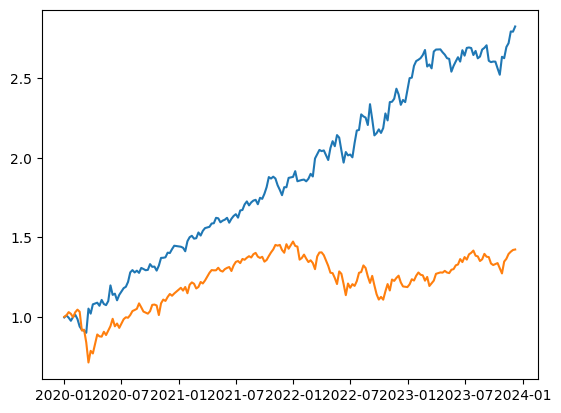

In [12]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [13]:
recommendations = trades.sort_values("date").tail(positions)

In [14]:
recommendations

,date,gics sector,adjclose,ticker,year,quarter,month,week,weekday,prediction,...,sp500_prediction,realtime_start,realtime_end,sp500,yield1,sp500_var,sp500_cov,market_expected_return,beta,excess_return
2187,2023-12-15 00:00:00+00:00,Real Estate,22.33,KIM,2023,4,12,50,4,23.630335,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2178,2023-12-15 00:00:00+00:00,Communication Services,23.40,NWSA,2023,4,12,50,4,28.060411,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-2.351825e-10,-0.000009,-inf,inf
2179,2023-12-15 00:00:00+00:00,Consumer Discretionary,36.08,TPR,2023,4,12,50,4,26.031151,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2180,2023-12-15 00:00:00+00:00,Consumer Staples,51.81,TSN,2023,4,12,50,4,32.564533,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2181,2023-12-15 00:00:00+00:00,Energy,17.49,KMI,2023,4,12,50,4,27.575602,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2182,2023-12-15 00:00:00+00:00,Financials,222.81,AJG,2023,4,12,50,4,28.134438,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-2.351825e-10,-0.000009,-inf,inf
2183,2023-12-15 00:00:00+00:00,Health Care,572.04,LLY,2023,4,12,50,4,32.564533,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-2.351825e-10,-0.000009,-inf,inf
2184,2023-12-15 00:00:00+00:00,Industrials,264.27,BA,2023,4,12,50,4,36.509792,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2185,2023-12-15 00:00:00+00:00,Information Technology,206.65,VRSN,2023,4,12,50,4,28.161600,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf
2186,2023-12-15 00:00:00+00:00,Materials,76.24,CF,2023,4,12,50,4,32.591694,...,4301.618384,2023-12-10,2023-12-10,4604.37,0.000718,0.0,-1.175912e-10,-0.000009,-inf,inf


In [15]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()